***Cell 0 — Mount Drive + Imports***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except:
    display = print

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)


Mounted at /content/drive


***Cell 1 — Load MovieLens 100K files***

In [ ]:
DATA_DIR = "/content/drive/MyDrive/A - EA Exercise/Movielens"
os.listdir(DATA_DIR)

ratings = pd.read_csv(
    f"{DATA_DIR}/u.data",
    sep="\t",
    names=["user_id", "item_id", "rating", "timestamp"]
)

users = pd.read_csv(
    f"{DATA_DIR}/u.user",
    sep="|",
    names=["user_id", "age", "gender", "occupation", "zip_code"]
)

items_raw = pd.read_csv(
    f"{DATA_DIR}/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# u.item: first 5 fields + 19 genre flags
item_cols = ["movie_id", "title", "release_date", "video_release_date", "imdb_url"] + [f"g{i}" for i in range(19)]
items_raw.columns = item_cols

genres = pd.read_csv(
    f"{DATA_DIR}/u.genre",
    sep="|",
    names=["genre", "genre_id"]
)

# Clean u.genre (drop possible empty last line)
genres_clean = genres.dropna(subset=["genre", "genre_id"]).copy()
genres_clean["genre_id"] = genres_clean["genre_id"].astype(int)
genres_clean = genres_clean.sort_values("genre_id").reset_index(drop=True)

display(ratings.head())
display(users.head())
display(items_raw.head())
display(genres_clean)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


,movie_id,title,release_date,video_release_date,imdb_url,g0,g1,g2,g3,g4,...,g9,g10,g11,g12,g13,g14,g15,g16,g17,g18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


,genre,genre_id
0,unknown,0
1,Action,1
2,Adventure,2
3,Animation,3
4,Children's,4
5,Comedy,5
6,Crime,6
7,Documentary,7
8,Drama,8
9,Fantasy,9


***Cell 2 — Build item→genre mapping + merge into ratings + save processed***

In [ ]:
# Build: item_id -> list of genre_ids
def get_genre_ids_from_row(row):
    return [i for i in range(19) if int(row[f"g{i}"]) == 1]

movie_genres_df = items_raw[["movie_id"] + [f"g{i}" for i in range(19)]].copy()
movie_genres_df["genre_ids"] = movie_genres_df.apply(get_genre_ids_from_row, axis=1)
movie_genres_df = movie_genres_df.rename(columns={"movie_id": "item_id"})[["item_id", "genre_ids"]]

ratings_with_genres = ratings.merge(movie_genres_df, on="item_id", how="left")
ratings_exploded = ratings_with_genres.explode("genre_ids").rename(columns={"genre_ids": "genre_id"})

print("ratings_with_genres:", ratings_with_genres.shape)
print("ratings_exploded   :", ratings_exploded.shape)
display(ratings_with_genres.head())
display(ratings_exploded.head())

# Save processed
PROCESSED_DIR = "/content/drive/MyDrive/A - EA Exercise/movielens/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

ratings_with_genres.to_csv(os.path.join(PROCESSED_DIR, "ratings_with_genres.csv"), index=False)
ratings_exploded.to_csv(os.path.join(PROCESSED_DIR, "ratings_exploded.csv"), index=False)

print("✅ Saved processed to:", PROCESSED_DIR)


ratings_with_genres: (100000, 5)
ratings_exploded   : (212595, 5)


,user_id,item_id,rating,timestamp,genre_ids
0,196,242,3,881250949,[5]
1,186,302,3,891717742,"[6, 10, 13, 16]"
2,22,377,1,878887116,"[4, 5]"
3,244,51,2,880606923,"[8, 14, 17, 18]"
4,166,346,1,886397596,"[6, 8]"


,user_id,item_id,rating,timestamp,genre_id
0,196,242,3,881250949,5
1,186,302,3,891717742,6
1,186,302,3,891717742,10
1,186,302,3,891717742,13
1,186,302,3,891717742,16


✅ Saved processed to: /content/drive/MyDrive/A - EA Exercise/movielens/processed


***Cell 3 — Per-user time-aware split (train/val/test) + save splits***

In [ ]:
SPLITS_DIR = "/content/drive/MyDrive/A - EA Exercise/movielens/splits_mf"
os.makedirs(SPLITS_DIR, exist_ok=True)

TEST_FRAC = 0.10
VAL_FRAC  = 0.20

MIN_RATINGS_PER_USER = 5
MIN_TEST_PER_USER = 10
MIN_VAL_PER_USER  = 5

def per_user_split(df, user_col="user_id", time_col="timestamp",
                   test_frac=0.10, val_frac=0.20, random_state=42,
                   min_ratings_per_user=5, min_test_per_user=1, min_val_per_user=1,
                   time_aware=True):
    rng_local = np.random.default_rng(random_state)
    train_parts, val_parts, test_parts = [], [], []

    for uid, g in df.groupby(user_col, sort=False):
        g = g.copy()
        n = len(g)

        if n < min_ratings_per_user:
            train_parts.append(g)
            continue

        n_test = max(min_test_per_user, int(round(n * test_frac)))
        n_val  = max(min_val_per_user,  int(round(n * val_frac)))

        if n_test + n_val >= n:
            n_test = min(n_test, n - 1)
            n_val  = min(n_val,  n - 1 - n_test)

        if time_aware and time_col in g.columns:
            g = g.sort_values(time_col)
            test = g.iloc[-n_test:] if n_test > 0 else g.iloc[0:0]
            remain = g.iloc[: n - n_test]
            val = remain.iloc[-n_val:] if n_val > 0 else remain.iloc[0:0]
            train = remain.iloc[: len(remain) - len(val)]
        else:
            idx = np.arange(n)
            rng_local.shuffle(idx)
            test_idx = idx[:n_test]
            val_idx  = idx[n_test:n_test+n_val]
            train_idx = idx[n_test+n_val:]
            test = g.iloc[test_idx]
            val  = g.iloc[val_idx]
            train = g.iloc[train_idx]

        train_parts.append(train)
        val_parts.append(val)
        test_parts.append(test)

    return (
        pd.concat(train_parts, ignore_index=True),
        pd.concat(val_parts,   ignore_index=True),
        pd.concat(test_parts,  ignore_index=True),
    )

rw_train, rw_val, rw_test = per_user_split(
    ratings_with_genres,
    test_frac=TEST_FRAC,
    val_frac=VAL_FRAC,
    random_state=RANDOM_STATE,
    min_ratings_per_user=MIN_RATINGS_PER_USER,
    min_test_per_user=MIN_TEST_PER_USER,
    min_val_per_user=MIN_VAL_PER_USER,
    time_aware=True
)

# Make exploded splits consistent with base splits
key_cols = ["user_id", "item_id", "timestamp"]

def filter_exploded(exploded_df, base_split_df):
    keys = base_split_df[key_cols].drop_duplicates()
    return exploded_df.merge(keys, on=key_cols, how="inner")

re_train = filter_exploded(ratings_exploded, rw_train)
re_val   = filter_exploded(ratings_exploded, rw_val)
re_test  = filter_exploded(ratings_exploded, rw_test)

# Save
rw_train.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_train.csv"), index=False)
rw_val.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_val.csv"), index=False)
rw_test.to_csv(os.path.join(SPLITS_DIR, "ratings_with_genres_test.csv"), index=False)

re_train.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_train.csv"), index=False)
re_val.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_val.csv"), index=False)
re_test.to_csv(os.path.join(SPLITS_DIR, "ratings_exploded_test.csv"), index=False)

print("✅ Saved splits to:", SPLITS_DIR)
print("train/val/test:", rw_train.shape, rw_val.shape, rw_test.shape)

train_users = set(rw_train["user_id"].unique())
test_users  = set(rw_test["user_id"].unique())
print("Cold-start users in test (should be 0):", len(test_users - train_users))


✅ Saved splits to: /content/drive/MyDrive/A - EA Exercise/movielens/splits_mf
train/val/test: (66680, 5) (20079, 5) (13241, 5)
Cold-start users in test (should be 0): 0


***Cell 4 — MF (NumPy SGD) + RMSE/MAE***

In [ ]:
from math import sqrt

# MF hyperparams
n_factors = 128
n_epochs  = 50
lr        = 0.01
reg       = 0.02
seed      = 42

def rmse_mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float32)
    y_pred = np.asarray(y_pred, dtype=np.float32)
    mse = np.mean((y_true - y_pred) ** 2)
    mae = np.mean(np.abs(y_true - y_pred))
    return float(np.sqrt(mse)), float(mae)

train = rw_train[["user_id","item_id","rating"]].copy()
val   = rw_val[["user_id","item_id","rating"]].copy()
test  = rw_test[["user_id","item_id","rating"]].copy()

# Build mappings from TRAIN
user_ids = train["user_id"].unique()
item_ids = train["item_id"].unique()
user2idx = {u:i for i,u in enumerate(user_ids)}
item2idx = {m:i for i,m in enumerate(item_ids)}

n_users = len(user2idx)
n_items = len(item2idx)

# Filter val/test to only ids seen in train
val_f = val[val["user_id"].isin(user2idx) & val["item_id"].isin(item2idx)].copy()
test_f = test[test["user_id"].isin(user2idx) & test["item_id"].isin(item2idx)].copy()

def to_idx(df):
    u = df["user_id"].map(user2idx).to_numpy(dtype=np.int32)
    i = df["item_id"].map(item2idx).to_numpy(dtype=np.int32)
    r = df["rating"].to_numpy(dtype=np.float32)
    return u, i, r

u_train, i_train, r_train = to_idx(train)
u_val, i_val, r_val       = to_idx(val_f)  if len(val_f)  else (np.array([],np.int32), np.array([],np.int32), np.array([],np.float32))
u_test, i_test, r_test    = to_idx(test_f) if len(test_f) else (np.array([],np.int32), np.array([],np.int32), np.array([],np.float32))

rng_mf = np.random.default_rng(seed)
P = 0.1 * rng_mf.standard_normal((n_users, n_factors)).astype(np.float32)
Q = 0.1 * rng_mf.standard_normal((n_items, n_factors)).astype(np.float32)
bu = np.zeros(n_users, dtype=np.float32)
bi = np.zeros(n_items, dtype=np.float32)
mu = np.mean(r_train).astype(np.float32)

def predict_idx(u_idx, i_idx):
    return mu + bu[u_idx] + bi[i_idx] + np.sum(P[u_idx] * Q[i_idx], axis=1)

print(f"Training MF: users={n_users}, items={n_items}, factors={n_factors}")
for epoch in range(1, n_epochs + 1):
    perm = rng_mf.permutation(len(r_train))
    u_sh, i_sh, r_sh = u_train[perm], i_train[perm], r_train[perm]

    for u, it, r in zip(u_sh, i_sh, r_sh):
        pred = mu + bu[u] + bi[it] + np.dot(P[u], Q[it])
        err = r - pred

        pu = P[u].copy()
        qi = Q[it].copy()

        bu[u] += lr * (err - reg * bu[u])
        bi[it] += lr * (err - reg * bi[it])
        P[u]  += lr * (err * qi - reg * pu)
        Q[it] += lr * (err * pu - reg * qi)

    tr_pred = predict_idx(u_train, i_train)
    tr_rmse, tr_mae = rmse_mae(r_train, tr_pred)

    if len(r_val):
        va_pred = predict_idx(u_val, i_val)
        va_rmse, va_mae = rmse_mae(r_val, va_pred)
        print(f"Epoch {epoch:02d}: Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f} | Val RMSE={va_rmse:.4f} MAE={va_mae:.4f}")
    else:
        print(f"Epoch {epoch:02d}: Train RMSE={tr_rmse:.4f} MAE={tr_mae:.4f} | Val: (no overlap)")

if len(r_test):
    te_pred = predict_idx(u_test, i_test)
    te_rmse, te_mae = rmse_mae(r_test, te_pred)
    print(f"\nFinal TEST: RMSE={te_rmse:.4f} MAE={te_mae:.4f}  (on {len(r_test)} interactions)")
else:
    print("\nFinal TEST: (no overlap)")


Training MF: users=943, items=1573, factors=128
Epoch 01: Train RMSE=0.9359 MAE=0.7454 | Val RMSE=1.0463 MAE=0.8348
Epoch 02: Train RMSE=0.8946 MAE=0.7092 | Val RMSE=1.0204 MAE=0.8099
Epoch 03: Train RMSE=0.8654 MAE=0.6854 | Val RMSE=1.0090 MAE=0.7994
Epoch 04: Train RMSE=0.8388 MAE=0.6643 | Val RMSE=1.0015 MAE=0.7930
Epoch 05: Train RMSE=0.8117 MAE=0.6427 | Val RMSE=0.9962 MAE=0.7880
Epoch 06: Train RMSE=0.7824 MAE=0.6195 | Val RMSE=0.9927 MAE=0.7848
Epoch 07: Train RMSE=0.7505 MAE=0.5944 | Val RMSE=0.9880 MAE=0.7811
Epoch 08: Train RMSE=0.7165 MAE=0.5681 | Val RMSE=0.9858 MAE=0.7791
Epoch 09: Train RMSE=0.6814 MAE=0.5406 | Val RMSE=0.9833 MAE=0.7769
Epoch 10: Train RMSE=0.6462 MAE=0.5129 | Val RMSE=0.9820 MAE=0.7758
Epoch 11: Train RMSE=0.6116 MAE=0.4857 | Val RMSE=0.9803 MAE=0.7742
Epoch 12: Train RMSE=0.5781 MAE=0.4591 | Val RMSE=0.9808 MAE=0.7743
Epoch 13: Train RMSE=0.5464 MAE=0.4343 | Val RMSE=0.9807 MAE=0.7742
Epoch 14: Train RMSE=0.5167 MAE=0.4109 | Val RMSE=0.9811 MAE=0.7745


***Cell 5 — Build candidate sets + MF baseline Top-K list (saved)***

In [ ]:
N_CANDIDATES = 300
RELEVANT_THRESHOLD = 4.0

RESULTS_DIR = "/content/drive/MyDrive/A - EA Exercise/results_mf"
os.makedirs(RESULTS_DIR, exist_ok=True)

# seen items per user from train+val
seen = (
    pd.concat([rw_train[["user_id","item_id"]], rw_val[["user_id","item_id"]]], ignore_index=True)
    .groupby("user_id")["item_id"].apply(set).to_dict()
)

test_relevant = (
    test_f[test_f["rating"] >= RELEVANT_THRESHOLD]
    .groupby("user_id")["item_id"].apply(set).to_dict()
)

all_train_items = set(item2idx.keys())

def mf_top_n_candidates(user_id, n=N_CANDIDATES):
    if user_id not in user2idx:
        return [], np.array([], dtype=np.float32)
    uidx = user2idx[user_id]

    seen_items = seen.get(user_id, set())
    candidates = list(all_train_items - seen_items)
    if not candidates:
        return [], np.array([], dtype=np.float32)

    cand_iidx = np.array([item2idx[iid] for iid in candidates], dtype=np.int32)
    u_arr = np.full_like(cand_iidx, fill_value=uidx)
    scores = predict_idx(u_arr, cand_iidx).astype(np.float32)

    nn = min(n, len(scores))
    topn_pos = np.argpartition(-scores, kth=nn-1)[:nn]
    topn_sorted = topn_pos[np.argsort(-scores[topn_pos])]

    cands_topN = [candidates[j] for j in topn_sorted]
    scs_topN = scores[topn_sorted]
    return cands_topN, scs_topN

# Users evaluated = users who have >=1 relevant item in test
users_eval = sorted(test_relevant.keys())

# MF baseline (fair): Top-K from Top-N candidates
mf_rows = []
for uid in users_eval:
    cands, scs = mf_top_n_candidates(uid, N_CANDIDATES)
    if len(cands) < K:
        continue
    recs = cands[:K]
    rec_scores = scs[:K]
    for rank, (iid, sc) in enumerate(zip(recs, rec_scores), start=1):
        mf_rows.append({"user_id": int(uid), "item_id": int(iid), "rank": int(rank), "pred_rating": float(sc)})

mf_recs_df = pd.DataFrame(mf_rows).sort_values(["user_id","rank"])
mf_path = os.path.join(RESULTS_DIR, f"mf_top{K}_from_top{N_CANDIDATES}_candidates.csv")
mf_recs_df.to_csv(mf_path, index=False)
print("✅ Saved MF baseline recs:", mf_path)
display(mf_recs_df.head())


✅ Saved MF baseline recs: /content/drive/MyDrive/A - EA Exercise/results_mf/mf_top10_from_top300_candidates.csv


,user_id,item_id,rank,pred_rating
0,1,511,1,5.398755
1,1,302,2,5.305768
2,1,357,3,5.225549
3,1,709,4,5.128717
4,1,318,5,5.075803


***Cell 6 — Genre helpers (ILD, constraint checks)***

In [ ]:
item_genres = {}
for _, row in items_raw.iterrows():
    iid = int(row["movie_id"])
    vec = row[[f"g{i}" for i in range(19)]].to_numpy(dtype=np.int8)
    item_genres[iid] = vec

genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))

def jaccard_distance(vec_a, vec_b):
    inter = np.sum((vec_a == 1) & (vec_b == 1))
    union = np.sum((vec_a == 1) | (vec_b == 1))
    return 0.0 if union == 0 else 1.0 - (inter / union)

def intra_list_diversity(item_list):
    if len(item_list) < 2:
        return 0.0
    vecs = [item_genres.get(int(i)) for i in item_list]
    vecs = [v for v in vecs if v is not None]
    n = len(vecs)
    if n < 2:
        return 0.0
    s, cnt = 0.0, 0
    for i in range(n):
        for j in range(i+1, n):
            s += jaccard_distance(vecs[i], vecs[j])
            cnt += 1
    return s / cnt if cnt else 0.0

def count_distinct_genres(item_list):
    gset = set()
    for iid in item_list:
        v = item_genres.get(int(iid))
        if v is None:
            continue
        gset |= set(np.where(v == 1)[0].tolist())
    return len(gset)

def genres_of_item(iid):
    v = item_genres.get(int(iid))
    if v is None:
        return []
    return [genre_name.get(int(g), str(g)) for g in np.where(v == 1)[0]]


# ***Cell 7 — ✅ STUDENT CELL: EA multi-objective algorithm must be implemented here***

***Students must output a list of K item_ids per user based on MF predicted scores + genres, optimizing accuracy + diversity with a category constraint.***

In [ ]:
# This is a sample of PSO implementation
'''
# ============================================================
# PSO multi-objective recommender (score + diversity + constraint)
# ============================================================

def ea_recommend_for_user(user_id, candidates, scores, K, item_genres):
    """
    Discrete PSO for recommendation list selection.

    Objectives (maximize):
      1) mean predicted rating (from MF scores)
      2) ILD diversity (genre Jaccard distance)

    Constraint:
      - at least MIN_DISTINCT_GENRES distinct genres in the recommended list

    Output:
      - list of K unique item_ids from candidates
    """

    # -------------------------
    # Hyperparameters (can be changed)
    # -------------------------
    N_PARTICLES = 50
    N_ITERS     = 50
    W_INERTIA   = 0.72
    C1          = 1.49
    C2          = 1.49

    W_SCORE = 0.8   # weight for accuracy
    W_ILD   = 0.2   # weight for diversity

    MIN_DISTINCT_GENRES = 3
    PENALTY_LAMBDA = 2.0   # bigger = stronger constraint enforcement

    # -------------------------
    # Edge cases
    # -------------------------
    nC = len(candidates)
    if nC <= K:
        # return all candidates (unique) if not enough
        return list(dict.fromkeys(candidates))[:K]

    scores = np.asarray(scores, dtype=np.float32)
    s_min, s_max = float(scores.min()), float(scores.max())
    s_rng = (s_max - s_min) if (s_max > s_min) else 1.0

    # Pre-fetch genre vectors for candidates for faster evaluation
    cand_genres = []
    for iid in candidates:
        v = item_genres.get(int(iid))
        if v is None:
            v = np.zeros(19, dtype=np.int8)
        cand_genres.append(v.astype(np.int8))
    cand_genres = np.stack(cand_genres, axis=0)  # (nC, 19)

    # -------------------------
    # Helpers
    # -------------------------
    def repair_to_k_unique(x):
        """Round/clip indices and enforce exactly K unique indices."""
        idx = np.clip(np.rint(x).astype(np.int32), 0, nC - 1)

        uniq = []
        used = set()
        for t in idx:
            t = int(t)
            if t not in used:
                uniq.append(t)
                used.add(t)
            if len(uniq) == K:
                break

        if len(uniq) < K:
            pool = [i for i in range(nC) if i not in used]
            need = K - len(uniq)
            if len(pool) >= need:
                fill = rng.choice(pool, size=need, replace=False).tolist()
            else:
                fill = rng.choice(pool if pool else np.arange(nC), size=need, replace=True).tolist()
            uniq.extend(fill)

        return np.array(uniq[:K], dtype=np.int32)

    def distinct_genres_count(idxs):
        """Count distinct genres present in selected items."""
        g_union = np.any(cand_genres[idxs] == 1, axis=0)
        return int(np.sum(g_union))

    def ild_of_indices(idxs):
        """ILD = average pairwise Jaccard distance among selected items."""
        if len(idxs) < 2:
            return 0.0
        vecs = cand_genres[idxs]  # (K, 19)
        s = 0.0
        cnt = 0
        for i in range(len(idxs)):
            for j in range(i + 1, len(idxs)):
                a = vecs[i]
                b = vecs[j]
                inter = np.sum((a == 1) & (b == 1))
                union = np.sum((a == 1) | (b == 1))
                dist = 0.0 if union == 0 else 1.0 - (inter / union)
                s += dist
                cnt += 1
        return float(s / cnt) if cnt > 0 else 0.0

    def enforce_genre_constraint(idxs):
        """
        Greedy repair: if distinct genres < MIN_DISTINCT_GENRES,
        replace low-score items with candidates that add new genres.
        """
        idxs = idxs.copy()
        chosen = set(map(int, idxs.tolist()))

        # current genre union
        g_union = np.any(cand_genres[idxs] == 1, axis=0)

        def score_of(i):  # i is candidate index
            return float(scores[i])

        # sort selected indices by score ascending (replace worst first)
        replace_order = sorted(idxs.tolist(), key=score_of)

        attempts = 0
        while int(np.sum(g_union)) < MIN_DISTINCT_GENRES and attempts < 200:
            attempts += 1

            # find a candidate not chosen that adds at least one new genre
            not_chosen = [i for i in range(nC) if i not in chosen]
            if not not_chosen:
                break

            # candidates that add new genres
            adders = []
            for j in not_chosen:
                v = cand_genres[j]
                if np.any((v == 1) & (~g_union)):
                    adders.append(j)

            if not adders:
                break

            # pick the best adder by score (you can also mix diversity here)
            best_new = max(adders, key=score_of)

            # replace one worst item
            if not replace_order:
                break
            worst = replace_order.pop(0)

            # execute replacement
            chosen.remove(int(worst))
            chosen.add(int(best_new))

            # update idxs and union
            idxs = np.array(list(chosen), dtype=np.int32)
            # re-trim to exactly K (should stay K)
            if len(idxs) > K:
                # drop lowest score extras
                idxs = np.array(sorted(idxs.tolist(), key=score_of, reverse=True)[:K], dtype=np.int32)
                chosen = set(map(int, idxs.tolist()))
            g_union = np.any(cand_genres[idxs] == 1, axis=0)

        # ensure exactly K
        if len(idxs) != K:
            # fill with highest-score unseen
            pool = [i for i in range(nC) if i not in chosen]
            pool_sorted = sorted(pool, key=lambda i: float(scores[i]), reverse=True)
            while len(idxs) < K and pool_sorted:
                j = pool_sorted.pop(0)
                chosen.add(int(j))
                idxs = np.array(list(chosen), dtype=np.int32)
            if len(idxs) > K:
                idxs = np.array(sorted(idxs.tolist(), key=score_of, reverse=True)[:K], dtype=np.int32)

        return idxs

    def objective(idxs):
        """
        Minimize: -(W_SCORE * score_norm + W_ILD * ild) + penalty
        """
        mean_score = float(np.mean(scores[idxs]))
        mean_score_norm = (mean_score - s_min) / s_rng  # [0,1] approx
        ild = ild_of_indices(idxs)                       # [0,1]

        distinct = distinct_genres_count(idxs)
        viol = max(0, MIN_DISTINCT_GENRES - distinct)
        penalty = PENALTY_LAMBDA * (viol ** 2)

        # maximize => minimize negative
        return - (W_SCORE * mean_score_norm + W_ILD * ild) + penalty

    # -------------------------
    # Initialize PSO particles
    # -------------------------
    X = np.zeros((N_PARTICLES, K), dtype=np.float32)
    V = np.zeros((N_PARTICLES, K), dtype=np.float32)

    for p in range(N_PARTICLES):
        X[p] = rng.choice(np.arange(nC), size=K, replace=False).astype(np.float32)

    pbest_X = X.copy()
    pbest_f = np.full(N_PARTICLES, np.inf, dtype=np.float32)

    gbest_X = None
    gbest_f = np.inf

    # Evaluate initial
    for p in range(N_PARTICLES):
        idxs = enforce_genre_constraint(repair_to_k_unique(X[p]))
        f = objective(idxs)
        pbest_f[p] = f
        pbest_X[p] = idxs.astype(np.float32)
        if f < gbest_f:
            gbest_f = f
            gbest_X = idxs.astype(np.float32)

    # -------------------------
    # PSO loop
    # -------------------------
    for _ in range(N_ITERS):
        for p in range(N_PARTICLES):
            r1 = rng.random(K, dtype=np.float32)
            r2 = rng.random(K, dtype=np.float32)

            V[p] = (W_INERTIA * V[p]
                    + C1 * r1 * (pbest_X[p] - X[p])
                    + C2 * r2 * (gbest_X - X[p]))
            X[p] = X[p] + V[p]

            idxs = enforce_genre_constraint(repair_to_k_unique(X[p]))
            f = objective(idxs)

            if f < pbest_f[p]:
                pbest_f[p] = f
                pbest_X[p] = idxs.astype(np.float32)

                if f < gbest_f:
                    gbest_f = f
                    gbest_X = idxs.astype(np.float32)

    # -------------------------
    # Return best particle as item_ids
    # -------------------------
    best_idxs = enforce_genre_constraint(repair_to_k_unique(gbest_X))
    rec_items = [int(candidates[i]) for i in best_idxs.tolist()]

    # final safety: unique + length K
    rec_items = list(dict.fromkeys(rec_items))
    if len(rec_items) < K:
        # fill with top-score unseen candidates
        chosen = set(rec_items)
        order = np.argsort(-scores)
        for j in order:
            iid = int(candidates[int(j)])
            if iid not in chosen:
                rec_items.append(iid)
                chosen.add(iid)
            if len(rec_items) == K:
                break

    return rec_items[:K]
'''


In [ ]:
# ============================================================
# STUDENT CELL (Define your algorithm function here)
# ============================================================

def ea_recommend_for_user(user_id, candidates, scores, K, item_genres, params):
    """
    Students must implement their own multi-objective EA / swarm algorithm that selects
    K unique items from the candidate pool.

    Inputs:
      user_id: int
      candidates: list[int]        # Top-N_CANDIDATES unseen items (by MF score)
      scores: np.array (float32)   # MF scores aligned with candidates
      K: int                       # final list size
      item_genres: dict[item_id] -> np.array(19,) binary genre flags
      params: dict                 # hyperparameters for the student algorithm

    Output:
      rec_list: list[int] of length K
        - unique
        - subset of candidates
        - no duplicates
    """
    raise NotImplementedError("Students must implement EA here.")


In [ ]:
# ============================================================
# STUDENT HYPERPARAMETERS (Define your hyperparameters here)
# ============================================================
# Top-k items
K=10

EA_PARAMS = {
    # --- common / required ---
    "seed": 42,
    "n_candidates": N_CANDIDATES,     # should remain N_CANDIDATES
    "k": K,                           # should remain K

    # --- multi-objective settings ---
    "w_score": 0.7,                   # if using weighted sum
    "w_div": 0.3,
    "min_distinct_genres": MIN_DISTINCT_GENRES,
    "penalty_lambda": 2.0,            # if using penalty approach

    # --- algorithm-specific placeholders (examples) ---
    # GA:
    "pop_size": 50,
    "n_gens": 50,
    "p_crossover": 0.9,
    "p_mutation": 0.2,
    "tournament_k": 3,

    # DE / ES / ACO etc. students can add their own keys:
    # "F": 0.5,
    # "CR": 0.9,
}

### ***Cell 8 — Run EA for all users and create recommendation file (uses your EA function)***

***Define your main run cell below. Students must edit or rewrite their main below to run the algorithm.***

In [ ]:
# from tqdm.auto import tqdm

EA_RESULTS_DIR = "/content/drive/MyDrive/A - EA Exercise/results_ea"
os.makedirs(EA_RESULTS_DIR, exist_ok=True)
EA_RECS_PATH = os.path.join(EA_RESULTS_DIR, f"ea_top{K}_from_top{N_CANDIDATES}_candidates.csv")

ea_rows = []
per_user_times = []
t_total0 = time.time()

try:
    for uid in tqdm(users_eval, desc="Running EA for users", unit="user"):
        t0 = time.time()

        candidates, scores = mf_top_n_candidates(uid, N_CANDIDATES)
        if len(candidates) < K:
            continue

        rec_list = ea_recommend_for_user(uid, candidates, scores, K, item_genres)
        # rec_list = ea_recommend_for_user(uid, candidates, scores, item_genres, EA_PARAMS)


        # Safety checks
        assert isinstance(rec_list, list), "EA output must be a list"
        assert len(rec_list) == K, f"EA must return exactly K={K} items"
        assert len(set(rec_list)) == K, "EA list must not contain duplicates"
        assert set(rec_list).issubset(set(candidates)), "EA list must be subset of candidates (Top-N)"

        score_map = {int(it): float(sc) for it, sc in zip(candidates, scores)}
        for rank, iid in enumerate(rec_list, start=1):
            ea_rows.append({
                "user_id": int(uid),
                "item_id": int(iid),
                "rank": int(rank),
                "pred_rating": float(score_map.get(int(iid), np.nan))
            })

        per_user_times.append(time.time() - t0)

except NotImplementedError:
    print("⚠️ EA not implemented yet.")
    print("Students must implement ea_recommend_for_user() in Cell 7.")
    raise

t_total = time.time() - t_total0

print("\n=== EA Runtime ===")
print(f"Total runtime: {t_total:.2f} s ({t_total/60:.2f} min)")
print(f"Users optimized: {len(per_user_times)}")
if per_user_times:
    print(f"Avg time/user: {np.mean(per_user_times):.4f} s")
    print(f"Median time/user: {np.median(per_user_times):.4f} s")
    print(f"Max time/user: {np.max(per_user_times):.4f} s")

ea_recs_df = pd.DataFrame(ea_rows).sort_values(["user_id","rank"])
ea_recs_df.to_csv(EA_RECS_PATH, index=False)
print("\n✅ Saved EA recs to:", EA_RECS_PATH)
display(ea_recs_df.head())


Running EA for users:   0%|          | 0/916 [00:00<?, ?user/s]


=== EA Runtime ===
Total runtime: 2609.14 s (43.49 min)
Users optimized: 916
Avg time/user: 2.8476 s
Median time/user: 2.5540 s
Max time/user: 4.8853 s

✅ Saved EA recs to: /content/drive/MyDrive/A - EA Exercise/results_ea/ea_top10_from_top300_candidates.csv


,user_id,item_id,rank,pred_rating
0,1,357,1,5.225549
1,1,603,2,4.877179
2,1,524,3,4.492660
3,1,511,4,5.398755
4,1,302,5,5.305768


***Cell 9 — Evaluation (Accuracy + Diversity + Constraint check)***

In [ ]:
from collections import Counter

def precision_at_k_list(lst, relevant_set, k):
    return len(set(lst[:k]) & relevant_set) / k if k > 0 else np.nan

def recall_at_k(lst, relevant, k):
    if len(relevant) == 0:
        return np.nan
    return len(set(lst[:k]) & relevant) / len(relevant)

def ndcg_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    dcg = 0.0
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan

def mrr_at_k_list(lst, relevant_set, k):
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            return 1.0 / rank
    return 0.0

def gini_from_counts(counts):
    x = np.sort(np.array(list(counts), dtype=np.float64))
    if x.sum() == 0:
        return np.nan
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

def entropy_norm_from_counts(counts):
    x = np.array(list(counts), dtype=np.float64)
    if x.sum() == 0:
        return np.nan
    p = x / x.sum()
    ent = float(-(p * np.log2(p + 1e-12)).sum())
    return ent / np.log2(len(p)) if len(p) > 1 else 0.0

def evaluate_recs_df(recs_df, name, K=10, min_distinct_genres=None):
    recs_df = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K).copy()
    user_lists = recs_df.groupby("user_id")["item_id"].apply(list)

    precs, recalls, ndcgs, mrrs, ilds = [], [], [], [], []
    genre_ok = []
    exposure = Counter()

    for uid, lst in user_lists.items():
        rel = test_relevant.get(uid, set())

        precs.append(precision_at_k_list(lst, rel, K))
        recalls.append(recall_at_k_list(lst, rel, K))
        ndcgs.append(ndcg_at_k_list(lst, rel, K))
        mrrs.append(mrr_at_k_list(lst, rel, K))
        ilds.append(intra_list_diversity(lst))

        if min_distinct_genres is not None:
            genre_ok.append(count_distinct_genres(lst) >= min_distinct_genres)

        for iid in lst[:K]:
            exposure[int(iid)] += 1

    unique_items = len(exposure)
    catalog_all = items_raw["movie_id"].nunique()
    catalog_train = len(all_train_items)

    return {
        "Model": name,
        f"Precision@{K}": float(np.nanmean(precs)),
        f"Recall@{K}": float(np.nanmean(recalls)),
        f"NDCG@{K}": float(np.nanmean(ndcgs)),
        f"MRR@{K}": float(np.mean(mrrs)),
        "ILD": float(np.mean(ilds)),
        f"Coverage@{K} (train)": float(unique_items / catalog_train) if catalog_train else np.nan,
        f"Coverage@{K} (all)": float(unique_items / catalog_all) if catalog_all else np.nan,
        "Gini": float(gini_from_counts(exposure.values())),
        "Entropy_norm": float(entropy_norm_from_counts(exposure.values())),
        "Users_evaluated": int(len(user_lists)),
        "Unique_items_recommended": int(unique_items),
        "Constraint_ok_rate": float(np.mean(genre_ok)) if len(genre_ok) else np.nan
    }

# Load MF baseline and EA results (if not in memory)
mf_recs_df = pd.read_csv(os.path.join(RESULTS_DIR, f"mf_numpy_top{K}_recs.csv"))
ea_recs_df = pd.read_csv(EA_RECS_PATH)

# Set your constraint threshold (or leave None if students handle it internally)
MIN_DISTINCT_GENRES = 3

mf_metrics = evaluate_recs_df(mf_recs_df, "MF baseline", K=K, min_distinct_genres=MIN_DISTINCT_GENRES)
ea_metrics = evaluate_recs_df(ea_recs_df, "EA (student)", K=K, min_distinct_genres=MIN_DISTINCT_GENRES)

compare = pd.DataFrame([mf_metrics, ea_metrics])
display(compare)


,Model,Precision@10,Recall@10,NDCG@10,MRR@10,ILD,Coverage@10 (train),Coverage@10 (all),Gini,Entropy_norm,Users_evaluated,Unique_items_recommended,Constraint_ok_rate
0,MF baseline,0.029621,0.032339,0.038276,0.094386,0.790053,0.247298,0.231272,0.705643,0.834523,844,389,1.0
1,EA (student),0.022052,0.029581,0.027724,0.061812,0.860310,0.440559,0.412010,0.655370,0.877274,916,693,1.0


# ***visualization***

***Helper functions for plotting***

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def build_user_lists(recs_df, K=10):
    recs_df = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K).copy()
    return recs_df.groupby("user_id")["item_id"].apply(list)

def precision_at_k_list(lst, relevant_set, k):
    return len(set(lst[:k]) & relevant_set) / k if k > 0 else np.nan

def recall_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    return len(set(lst[:k]) & relevant_set) / len(relevant_set)

def ndcg_at_k_list(lst, relevant_set, k):
    if len(relevant_set) == 0:
        return np.nan
    dcg = 0.0
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            dcg += 1.0 / np.log2(rank + 1)
    ideal = min(len(relevant_set), k)
    idcg = sum(1.0 / np.log2(r + 1) for r in range(1, ideal + 1))
    return dcg / idcg if idcg > 0 else np.nan

def mrr_at_k_list(lst, relevant_set, k):
    for rank, iid in enumerate(lst[:k], start=1):
        if iid in relevant_set:
            return 1.0 / rank
    return 0.0

def mean_pred_score_for_user(recs_df, score_col="pred_rating", K=10):
    # If pred_rating exists, use it. Otherwise return NaN.
    if score_col not in recs_df.columns:
        return pd.Series(dtype=float)
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    return tmp.groupby("user_id")[score_col].mean()

def exposure_counts(recs_df, K=10):
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    return tmp["item_id"].value_counts()

def lorenz_curve_from_counts(counts):
    x = np.sort(np.array(list(counts), dtype=np.float64))
    if x.sum() == 0:
        return np.array([0.0, 1.0])
    cum = np.cumsum(x)
    cum = np.insert(cum, 0, 0)
    return cum / cum[-1]

def coverage_curve(recs_df, catalog_items, max_k=20):
    # catalog_items = set of recommendable items (train items is fair for MF)
    cov = []
    for kk in range(1, max_k+1):
        sub = recs_df[recs_df["rank"] <= kk]
        cov.append(sub["item_id"].nunique() / len(catalog_items) if len(catalog_items) else np.nan)
    return np.array(cov, dtype=float)


***Per-user tradeoff scatter: Mean score vs ILD (MF vs EA)***

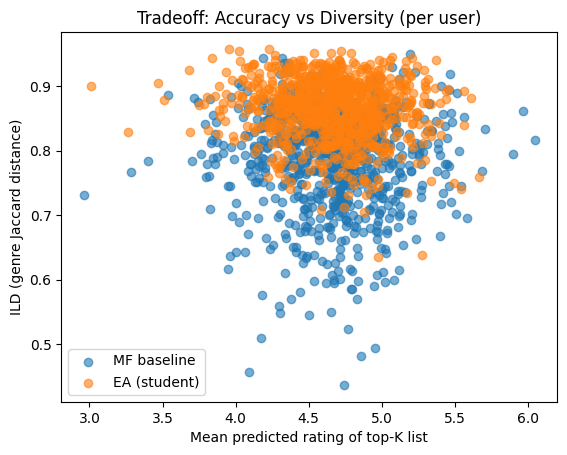

In [ ]:
K = 10

mf_lists = build_user_lists(mf_recs_df, K)
ea_lists = build_user_lists(ea_recs_df, K)

mf_ild = mf_lists.apply(intra_list_diversity)
ea_ild = ea_lists.apply(intra_list_diversity)

mf_mean_score = mean_pred_score_for_user(mf_recs_df, K=K)
ea_mean_score = mean_pred_score_for_user(ea_recs_df, K=K)

# align users (intersection)
common_users = sorted(set(mf_lists.index) & set(ea_lists.index))
x_mf = mf_mean_score.reindex(common_users).to_numpy()
y_mf = mf_ild.reindex(common_users).to_numpy()
x_ea = ea_mean_score.reindex(common_users).to_numpy()
y_ea = ea_ild.reindex(common_users).to_numpy()

plt.figure()
plt.scatter(x_mf, y_mf, alpha=0.6, label="MF baseline")
plt.scatter(x_ea, y_ea, alpha=0.6, label="EA (student)")
plt.xlabel("Mean predicted rating of top-K list")
plt.ylabel("ILD (genre Jaccard distance)")
plt.title("Tradeoff: Accuracy vs Diversity (per user)")
plt.legend()
plt.show()


***Catalog coverage vs K curve (train-catalog is fair)***

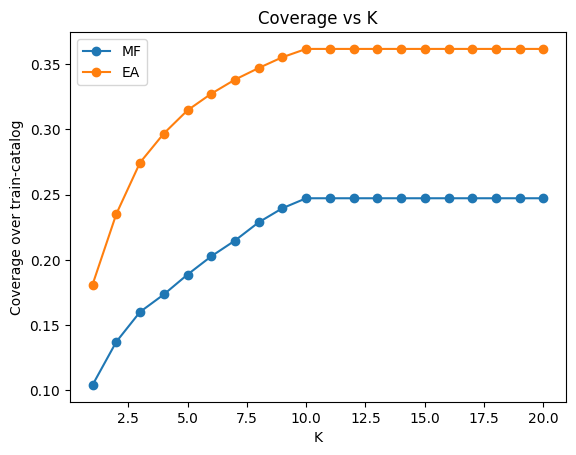

In [ ]:
max_k = 20
mf_cov = coverage_curve(mf_recs_df, catalog_items=all_train_items, max_k=max_k)
ea_cov = coverage_curve(ea_recs_df, catalog_items=all_train_items, max_k=max_k)

plt.figure()
plt.plot(range(1, max_k+1), mf_cov, marker="o", label="MF")
plt.plot(range(1, max_k+1), ea_cov, marker="o", label="EA")
plt.xlabel("K")
plt.ylabel("Coverage over train-catalog")
plt.title("Coverage vs K")
plt.legend()
plt.show()


***Exposure inequality: log-log exposure + Lorenz curve***

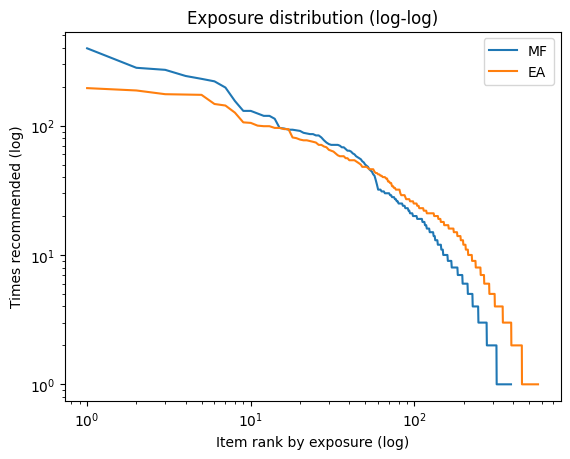

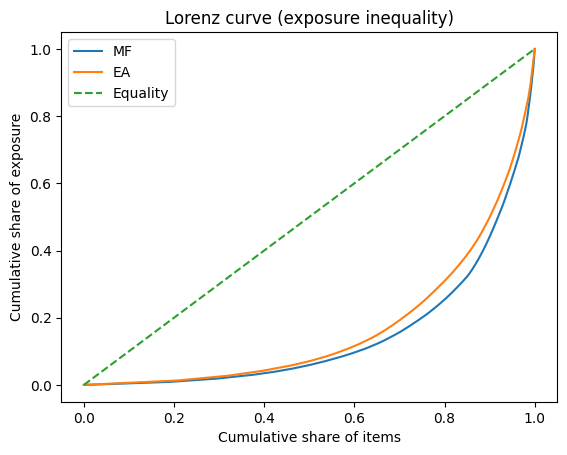

In [ ]:
mf_exp = exposure_counts(mf_recs_df, K=K)
ea_exp = exposure_counts(ea_recs_df, K=K)

# Log-log exposure (popular items get recommended a lot?)
mf_vals = mf_exp.sort_values(ascending=False).to_numpy()
ea_vals = ea_exp.sort_values(ascending=False).to_numpy()

plt.figure()
plt.plot(range(1, len(mf_vals)+1), mf_vals, label="MF")
plt.plot(range(1, len(ea_vals)+1), ea_vals, label="EA")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Item rank by exposure (log)")
plt.ylabel("Times recommended (log)")
plt.title("Exposure distribution (log-log)")
plt.legend()
plt.show()

# Lorenz curve
mf_l = lorenz_curve_from_counts(mf_exp.values)
ea_l = lorenz_curve_from_counts(ea_exp.values)

plt.figure()
plt.plot(np.linspace(0,1,len(mf_l)), mf_l, label="MF")
plt.plot(np.linspace(0,1,len(ea_l)), ea_l, label="EA")
plt.plot([0,1],[0,1], linestyle="--", label="Equality")
plt.xlabel("Cumulative share of items")
plt.ylabel("Cumulative share of exposure")
plt.title("Lorenz curve (exposure inequality)")
plt.legend()
plt.show()


***Genre distribution in recommended lists (what genres does model expose?)***

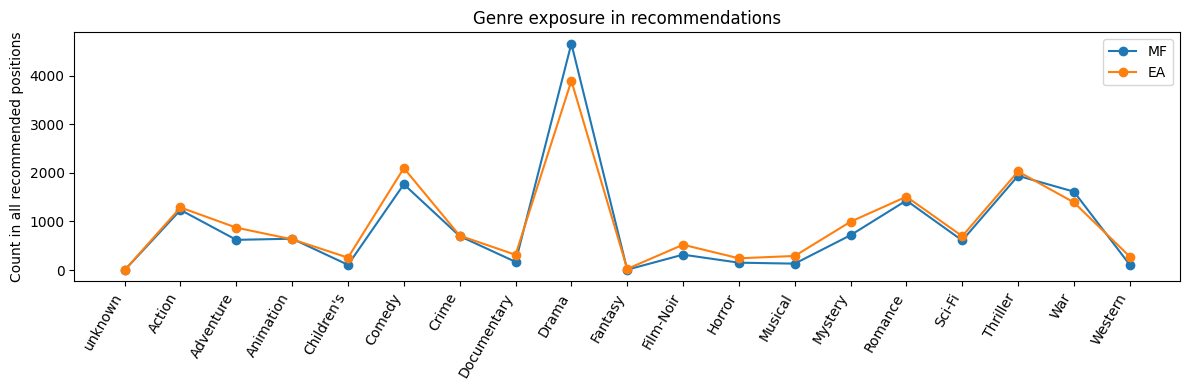

In [ ]:
def genre_hist(recs_df, K, item_genres):
    tmp = recs_df.sort_values(["user_id","rank"]).groupby("user_id").head(K)
    counts = Counter()
    for iid in tmp["item_id"].astype(int).tolist():
        v = item_genres.get(iid)
        if v is None:
            continue
        for gid in np.where(v == 1)[0]:
            counts[int(gid)] += 1
    return counts

mf_g = genre_hist(mf_recs_df, K, item_genres)
ea_g = genre_hist(ea_recs_df, K, item_genres)

# Align to 0..18
x = np.arange(19)
mf_y = np.array([mf_g.get(i,0) for i in x])
ea_y = np.array([ea_g.get(i,0) for i in x])

# Genre names
genre_name = dict(zip(genres_clean["genre_id"].astype(int), genres_clean["genre"].astype(str)))
labels = [genre_name.get(i, str(i)) for i in x]

plt.figure(figsize=(12,4))
plt.plot(x, mf_y, marker="o", label="MF")
plt.plot(x, ea_y, marker="o", label="EA")
plt.xticks(x, labels, rotation=60, ha="right")
plt.ylabel("Count in all recommended positions")
plt.title("Genre exposure in recommendations")
plt.legend()
plt.tight_layout()
plt.show()


***Qualitative: show one user’s MF vs EA lists (titles + genres)***

In [ ]:
def show_user_lists(uid, K=10):
    mf_list = mf_lists.get(uid, [])
    ea_list = ea_lists.get(uid, [])

    def to_table(lst, name):
        rows = []
        for rank, iid in enumerate(lst[:K], start=1):
            title = items_raw.loc[items_raw["movie_id"]==int(iid), "title"]
            title = title.iloc[0] if len(title) else "UNKNOWN"
            gnames = genre_names_for_item(iid, genres_clean, item_genres)
            rows.append({"model": name, "rank": rank, "item_id": int(iid), "title": title, "genres": ", ".join(gnames)})
        return pd.DataFrame(rows)

    out = pd.concat([to_table(mf_list, "MF"), to_table(ea_list, "EA")], ignore_index=True)
    display(out)

# pick any user that exists
example_user = common_users[0]
print("Example user:", example_user)
show_user_lists(example_user, K=K)


Example user: 1


,model,rank,item_id,title,genres
0,MF,1,9,Dead Man Walking (1995),Drama
1,MF,2,408,"Close Shave, A (1995)","Animation, Comedy, Thriller"
2,MF,3,302,L.A. Confidential (1997),"Crime, Film-Noir, Mystery, Thriller"
3,MF,4,647,Ran (1985),"Drama, War"
4,MF,5,169,"Wrong Trousers, The (1993)","Animation, Comedy"
5,MF,6,285,Secrets & Lies (1996),Drama
6,MF,7,652,Rosencrantz and Guildenstern Are Dead (1990),"Comedy, Drama"
7,MF,8,430,Duck Soup (1933),"Comedy, War"
8,MF,9,1449,Pather Panchali (1955),Drama
9,MF,10,171,Delicatessen (1991),"Comedy, Sci-Fi"
